# 06 — คณะรัฐศาสตร์: the four majors, TCAS66–69

**Consumes** `data/TCAS{66,67,68,69}_maxmin.xlsx` through `src.load` — the same
tidy loader and assertions as `nb/01_clean`. Nothing is re-parsed by hand.

**Emits**
- `data/processed/polisci_major_panel.csv` — balanced 4-major × 4-year panel.
- `data/processed/polisci_route_panel.csv` — the full major × elective × year grid.
- five figures to `reports/figures/09..13_polisci_*.png`.

**Concludes** the faculty-level headline for รัฐศาสตร์ (+3.7 raw points, 66→69)
is **less than half a real move in entry standards**. Once the changing mix of
elective-exam routes is controlled for, the faculty rises **+1.7**. The rest is
composition: รัฐประศาสนศาสตร์'s cheap language routes stopped admitting anyone,
so they dropped out of the median that produced +3.7.

Underneath the faculty average the four majors are not one story. Applications
split four ways — ความสัมพันธ์ระหว่างประเทศ **−65%**, สังคมวิทยาฯ **−50%**,
การปกครอง **+5%**, รัฐประศาสนศาสตร์ **+255%** — while every floor moved by only
a few points and all four peaked in TCAS68.

This notebook is self-contained end-to-end: clean → analyse → visualise. It
reuses `src.load` (loader, Chula filter, trap-aware helpers) and `src.viz`
(verified Thai font, shared palette) rather than duplicating them.

> Not the spec's `nb/06_findings.ipynb`, which was never written — this is a
> separate faculty-level study.

In [1]:
import sys; sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.load import load_all, chula, PROCESSED
from src.normalize import with_percentile_rank
from src import viz

viz.setup()                       # raises if Thai would render as tofu
pd.set_option("display.width", 220)

FACULTY = "คณะรัฐศาสตร์"
YEARS = (66, 67, 68, 69)

---
## 1. Clean — two dimensions hidden inside one column

รัฐศาสตร์ publishes under a **single** `รหัสหลักสูตร` and a single
`ชื่อหลักสูตร`. Every distinction that matters is packed into `รายละเอียด`.

In [2]:
raw = with_percentile_rank(load_all())
ps = chula(raw)
ps = ps[ps["faculty"] == FACULTY].copy()

print(f"rows: {len(ps)}  ·  codes: {ps['code'].nunique()}  ·  programs: {ps['program'].nunique()}")
print(f"code    : {ps['code'].unique()[0]}")
print(f"program : {ps['program'].unique()[0]}")
ps.groupby("year").size().rename("rows").to_frame().T

rows: 121  ·  codes: 1  ·  programs: 1
code    : 10010124903201A
program : หลักสูตรรัฐศาสตรบัณฑิต


year,66,67,68,69
rows,30,30,30,31


One code, one program, ~30 rows a year. The rows are the *cross product* of two
things `รายละเอียด` concatenates:

```
สาขาวิชาการปกครอง เลือกสอบวิชาภาษาญี่ปุ่น
└─── major (สาขาวิชา) ───┘└─ elective exam (เลือกสอบวิชา) ─┘
```

`สาขา/วิชาเอก` already carries the major cleanly, so only the **elective** has
to be parsed out — and the parse is asserted to round-trip, not trusted.

In [3]:
ps["elective"] = ps["detail"].str.extract(r"เลือกสอบวิชา(.+)$")[0].str.strip()

# Round-trip: the parse must reconstruct `detail` exactly, for every row.
rebuilt = "สาขาวิชา" + ps["major"] + " เลือกสอบวิชา" + ps["elective"]
assert rebuilt.equals(ps["detail"]), "elective parse does not round-trip"
assert ps["elective"].notna().all(), "a row carries no เลือกสอบวิชา"

print(f"majors    ({ps['major'].nunique()}): {', '.join(sorted(ps['major'].unique()))}")
print(f"electives ({ps['elective'].nunique()}): {', '.join(sorted(ps['elective'].unique()))}")

majors    (4): การปกครอง, ความสัมพันธ์ระหว่างประเทศ, รัฐประศาสนศาสตร์, สังคมวิทยาและมานุษยวิทยา
electives (9): คณิตศาสตร์ประยุกต์ 2, ภาษาจีน, ภาษาญี่ปุ่น, ภาษาฝรั่งเศส, ภาษาสเปน, ภาษาอังกฤษ, ภาษาเกาหลี, ภาษาเยอรมัน, ภาษาไทย


So the real grain is **major × elective route × year** — 121 rows over four
years. The route menu is not the same for every major, and it is not stable
over time:

In [4]:
grid = ps.pivot_table(index="major", columns="elective", values="year",
                      aggfunc="count").fillna(0).astype(int)
grid.loc["— total —"] = grid.sum()
grid   # cell value = how many of the 4 years that route was published

elective,คณิตศาสตร์ประยุกต์ 2,ภาษาจีน,ภาษาญี่ปุ่น,ภาษาฝรั่งเศส,ภาษาสเปน,ภาษาอังกฤษ,ภาษาเกาหลี,ภาษาเยอรมัน,ภาษาไทย
major,,,,,,,,,
การปกครอง,4,4,4,4,4,0,4,4,0
ความสัมพันธ์ระหว่างประเทศ,4,4,4,4,4,0,4,4,4
รัฐประศาสนศาสตร์,3,4,4,4,4,2,4,4,0
สังคมวิทยาและมานุษยวิทยา,4,4,4,4,4,0,4,4,4
— total —,15,16,16,16,16,2,16,16,8


Three structural facts fall straight out of this table, and each one shapes the
analysis that follows:

- **ภาษาไทย is offered only by ความสัมพันธ์ระหว่างประเทศ and สังคมวิทยาฯ.**
  It is also the single largest route by applications in both.
- **ภาษาอังกฤษ exists for only 2 of 4 years, in only one major** — it appears in
  รัฐประศาสนศาสตร์ in TCAS68 and did not exist before. That is a criteria
  change, and §6 shows it reorganised the whole major.
- **คณิตศาสตร์ประยุกต์ 2 is missing one year** — รัฐประศาสนศาสตร์ dropped it in
  TCAS68 and brought it back in 69.

A route menu that changes between years is exactly the kind of thing that
produces a fake trend, so the panel is built to be robust to it.

---
## 2. Seats — รัฐศาสตร์ is the clean case of Trap 1

Trap 1 says `รับ` cannot be summed: one code fans out into many rows repeating a
shared quota, and faculty-wide the best reconstruction lands *below* actual
admits. Inside รัฐศาสตร์ the mechanism is visible in its simplest form — and
here it fully resolves.

In [5]:
seats = ps.groupby(["year", "major"]).agg(
    rows=("code", "size"),
    distinct_quotas=("seats", "nunique"),
    quota=("seats", "max"),
    raw_sum=("seats", "sum"),
    admits=("passed", "sum"),
)
# Exactly one quota per (major, year) -- so the shared-pool structure is
# unambiguous here, unlike อักษรศาสตร์ where one code holds two distinct pools.
assert (seats["distinct_quotas"] == 1).all(), "a major-year carries >1 quota"
seats

rows  distinct_quotas  quota  raw_sum  admits
year major                                                                   
66   การปกครอง                     7                1   61.0    427.0    61.0
     ความสัมพันธ์ระหว่างประเทศ     8                1   66.0    528.0    66.0
     รัฐประศาสนศาสตร์              7                1   66.0    462.0    66.0
     สังคมวิทยาและมานุษยวิทยา      8                1   61.0    488.0    61.0
67   การปกครอง                     7                1   61.0    427.0    61.0
     ความสัมพันธ์ระหว่างประเทศ     8                1   66.0    528.0    66.0
     รัฐประศาสนศาสตร์              7                1   66.0    462.0    66.0
     สังคมวิทยาและมานุษยวิทยา      8                1   61.0    488.0    61.0
68   การปกครอง                     7                1   61.0    427.0    61.0
     ความสัมพันธ์ระหว่างประเทศ     8                1   66.0    528.0    66.0
     รัฐประศาสนศาสตร์              7                1   66.0    462.0    66.0
     สังคมวิทยาและมานุษยวิทยา      8                1   61.0    488.0    61.0
69   การปกครอง                     7                1   61.0    427.0    61.0
     ความสัมพันธ์ระหว่างประเทศ     8                1   66.0    528.0    66.0
     รัฐประศาสนศาสตร์              8                1   67.0    536.0    67.0
     สังคมวิทยาและมานุษยวิทยา      8                1   64.0    512.0    64.0

In [6]:
print(f"raw sum() over-counts by {seats['raw_sum'].sum() / seats['quota'].sum():.1f}x "
      f"({seats['raw_sum'].sum():,.0f} vs {seats['quota'].sum():,.0f})")
print(f"quota == admits in {(seats['quota'] == seats['admits']).sum()} of {len(seats)} major-years")

raw sum() over-counts by 7.6x (7,718 vs 1,020)
quota == admits in 16 of 16 major-years


**Every major fills its quota exactly, every year.** That is a materially
different situation from the faculty-wide picture, where reconstructed seats
come out below admits in all four years and no seat number is usable.

The consequence for everything below: **supply is frozen by decree.**

In [7]:
supply = ps.groupby(["year", "major"])["seats"].max().unstack()
supply["FACULTY"] = supply.sum(axis=1)
supply.astype(int)

major,การปกครอง,ความสัมพันธ์ระหว่างประเทศ,รัฐประศาสนศาสตร์,สังคมวิทยาและมานุษยวิทยา,FACULTY
year,,,,,
66,61,66,66,61,254
67,61,66,66,61,254
68,61,66,66,61,254
69,61,66,67,64,258


254 → 254 → 254 → 258 seats. Three majors never move at all; รัฐประศาสนศาสตร์
gains 1 seat and สังคมวิทยาฯ 3, both in TCAS69.

So no movement in any score below can be attributed to the faculty admitting
more or fewer students. **Every change is demand-side or criteria-side.** That
makes รัฐศาสตร์ an unusually clean natural experiment inside this dataset.

---
## 3. Build the panels

Two panels, because the analysis has two levels. Both apply Trap 2's rule:
score aggregates use **`passed > 0`**, never `min_score > 0`.

At Chula a route that admitted nobody publishes `min_score == 0`, and averaging
that zero into a major's floor would be catastrophic — §4 shows it would print a
floor of 0.0 for รัฐประศาสนศาสตร์ in two of four years.

In [8]:
live = ps[ps["passed"] > 0]          # Trap 2: validity filter is on admits

major_panel = live.groupby(["major", "year"]).agg(
    floor=("min_score", "min"),          # the program's true entry point
    floor_med=("min_score", "median"),   # robust to one thin route
    top=("max_score", "max"),
    pct_rank=("pct_rank", "median"),     # scale-free, vs the national field
    live_routes=("code", "size"),
).join(
    ps.groupby(["major", "year"]).agg(
        routes=("code", "size"), applied=("applied", "sum"),
        passed=("passed", "sum"), quota=("seats", "max"),
    )
)
major_panel["apps_per_admit"] = major_panel["applied"] / major_panel["passed"]
major_panel["dead_routes"] = major_panel["routes"] - major_panel["live_routes"]

assert len(major_panel) == 4 * 4, "major panel is not balanced"
major_panel.round(2)

floor  floor_med    top  pct_rank  live_routes  routes  applied  passed  quota  apps_per_admit  dead_routes
major                     year                                                                                                             
การปกครอง                 66    64.78      64.97  81.36     78.65            5       7    979.0    61.0   61.0           16.05            2
                          67    63.29      63.47  83.40     75.59            6       7   1868.0    61.0   61.0           30.62            1
                          68    70.87      71.23  77.46     83.66            7       7   1911.0    61.0   61.0           31.33            0
                          69    66.88      67.35  86.59     78.56            6       7   1026.0    61.0   61.0           16.82            1
ความสัมพันธ์ระหว่างประเทศ 66    74.81      76.08  83.03     89.99            8       8   4641.0    66.0   66.0           70.32            0
                          67    73.30      76.25  86.74     88.67            8       8   3480.0    66.0   66.0           52.73            0
                          68    78.25      78.97  88.16     90.99            8       8   2768.0    66.0   66.0           41.94            0
                          69    73.99      74.70  87.64     87.34            6       8   1621.0    66.0   66.0           24.56            2
รัฐประศาสนศาสตร์          66    62.85      64.43  74.97     77.80            7       7    621.0    66.0   66.0            9.41            0
                          67    63.25      63.33  71.25     75.38            7       7   1376.0    66.0   66.0           20.85            0
                          68    68.16      68.34  77.30     79.71            2       7    826.0    66.0   66.0           12.52            5
                          69    68.30      68.33  74.19     79.72            3       8   2203.0    67.0   67.0           32.88            5
สังคมวิทยาและมานุษยวิทยา  66    70.12      70.12  83.90     84.65            3       8   2786.0    61.0   61.0           45.67            5
                          67    69.79      70.06  75.94     83.13            5       8   2550.0    61.0   61.0           41.80            3
                          68    73.30      73.42  80.61     86.24            6       8   1902.0    61.0   61.0           31.18            2
                          69    69.99      70.38  82.69     82.80            6       8   1381.0    64.0   64.0           21.58            2

In [9]:
route_panel = ps.groupby(["major", "elective", "year"]).agg(
    applied=("applied", "sum"), passed=("passed", "sum"),
    min_score=("min_score", "min"), max_score=("max_score", "max"),
    quota=("seats", "max"),
).reset_index()
# A route with no admits has no floor -- blank it rather than carrying the 0.
route_panel.loc[route_panel["passed"] == 0, ["min_score", "max_score"]] = np.nan
print(f"route panel: {len(route_panel)} rows")
route_panel.head(4)

route panel: 121 rows


,major,elective,year,applied,passed,min_score,max_score,quota
0,การปกครอง,คณิตศาสตร์ประยุกต์ 2,66,505.0,37.0,64.7750,81.3583,61.0
1,การปกครอง,คณิตศาสตร์ประยุกต์ 2,67,1212.0,28.0,63.2916,70.2083,61.0
2,การปกครอง,คณิตศาสตร์ประยุกต์ 2,68,1238.0,37.0,70.8694,77.4583,61.0
3,การปกครอง,คณิตศาสตร์ประยุกต์ 2,69,599.0,46.0,66.8798,86.5853,61.0


### Why the `passed > 0` filter is not optional here

Side by side, on the two majors where dead routes are common:

In [10]:
naive = ps.groupby(["major", "year"])["min_score"].median().unstack()
correct = live.groupby(["major", "year"])["min_score"].median().unstack()
pd.concat({"naive (all rows)": naive, "correct (passed > 0)": correct},
          axis=1).round(2).loc[["รัฐประศาสนศาสตร์", "สังคมวิทยาและมานุษยวิทยา"]]

naive (all rows)                     correct (passed > 0)                     
year                                   66     67     68    69                   66     67     68     69
major                                                                                                  
รัฐประศาสนศาสตร์                    64.43  63.33   0.00   0.0                64.43  63.33  68.34  68.33
สังคมวิทยาและมานุษยวิทยา             0.00  69.90  73.38  70.2                70.12  70.06  73.42  70.38

The naive version prints **0.00** for รัฐประศาสนศาสตร์ in TCAS68 and 69, and for
สังคมวิทยาฯ in TCAS66 — not because standards collapsed but because more than
half the published routes admitted nobody that year. Those zeroes are Trap 2
firing exactly as documented.

---
## 4. Scores by major over time

The question the project asks of the faculty, asked of each major separately.

In [11]:
view = major_panel.reset_index().pivot(index="major", columns="year")
scores = pd.concat({
    "floor (raw)": view["floor"],
    "percentile rank": view["pct_rank"],
}, axis=1)
scores.round(2)

floor (raw)                      percentile rank                     
year                               66     67     68     69              66     67     68     69
major                                                                                          
การปกครอง                       64.78  63.29  70.87  66.88           78.65  75.59  83.66  78.56
ความสัมพันธ์ระหว่างประเทศ       74.81  73.30  78.25  73.99           89.99  88.67  90.99  87.34
รัฐประศาสนศาสตร์                62.85  63.25  68.16  68.30           77.80  75.38  79.71  79.72
สังคมวิทยาและมานุษยวิทยา        70.12  69.79  73.30  69.99           84.65  83.13  86.24  82.80

In [12]:
delta = pd.DataFrame({
    "floor 66": view[("floor", 66)], "floor 69": view[("floor", 69)],
    "Δ raw": view[("floor", 69)] - view[("floor", 66)],
    "Δ raw 66→68": view[("floor", 68)] - view[("floor", 66)],
    "pct 66": view[("pct_rank", 66)], "pct 69": view[("pct_rank", 69)],
    "Δ pct": view[("pct_rank", 69)] - view[("pct_rank", 66)],
}).sort_values("Δ raw")
delta.round(2)

,floor 66,floor 69,Δ raw,Δ raw 66→68,pct 66,pct 69,Δ pct
major,,,,,,,
ความสัมพันธ์ระหว่างประเทศ,74.81,73.99,-0.82,3.44,89.99,87.34,-2.65
สังคมวิทยาและมานุษยวิทยา,70.12,69.99,-0.12,3.18,84.65,82.80,-1.85
การปกครอง,64.78,66.88,2.10,6.09,78.65,78.56,-0.10
รัฐประศาสนศาสตร์,62.85,68.30,5.45,5.31,77.80,79.72,1.92


Two patterns, and they matter in opposite directions:

**1. A common TCAS68 peak — with one exception.** Three of the four majors rise
into TCAS68 (+3.2 to +6.1) and give it back in 69 (−3.3 to −4.3).
**รัฐประศาสนศาสตร์ does not**: it rises with the others (+5.3) and then *holds*
(+0.14 raw, +0.02 percentile), making 69 its peak. It is also the major that
restructured in TCAS68 (§6), so the one major that broke the common shape is the
one whose criteria changed.

How much of the 68 spike is just an easier year? The national median moved
50.64 → 53.85 → 52.66, so **+3.2 then −1.2**. Against that:

- **All four gained percentile rank into 68** (+1.0 to +5.0), so the spike is not
  purely exam drift — they moved up *relative to the national field* as well.
- But for ความสัมพันธ์ฯ (+3.4 raw) and สังคมวิทยาฯ (+3.2 raw) the raw rise is
  almost exactly the national +3.2, and their percentile gain is only +1.0 and
  +1.6. **Most of their raw spike is drift.** การปกครอง (+6.1 raw, +5.0
  percentile) is the one clear real move.

This is the normalized track earning its keep: on raw points all four look like
the same story, and they are not.

**2. The four-year net change is small and the ordering barely moves.**
ความสัมพันธ์ระหว่างประเทศ is the hardest entry every single year and
รัฐประศาสนศาสตร์ the easiest in three of four. The gap between them narrows from
**11.96** points to **5.69** — the only large structural change, and §6 shows it
is a criteria change rather than a shift in student preference.

---
## 5. Demand splits four ways — and the floors barely notice

The faculty lost 31% of its applications. That total conceals a four-way split
in which two majors halve and one more than triples.

In [13]:
demand = pd.DataFrame({
    "apps 66": view[("applied", 66)], "apps 69": view[("applied", 69)],
    "Δ apps %": 100 * (view[("applied", 69)] / view[("applied", 66)] - 1),
    "apps/admit 66": view[("apps_per_admit", 66)],
    "apps/admit 69": view[("apps_per_admit", 69)],
    "Δ raw": view[("floor", 69)] - view[("floor", 66)],
    "Δ pct": view[("pct_rank", 69)] - view[("pct_rank", 66)],
}).sort_values("Δ apps %")
demand.round(1)

,apps 66,apps 69,Δ apps %,apps/admit 66,apps/admit 69,Δ raw,Δ pct
major,,,,,,,
ความสัมพันธ์ระหว่างประเทศ,4641.0,1621.0,-65.1,70.3,24.6,-0.8,-2.6
สังคมวิทยาและมานุษยวิทยา,2786.0,1381.0,-50.4,45.7,21.6,-0.1,-1.9
การปกครอง,979.0,1026.0,4.8,16.0,16.8,2.1,-0.1
รัฐประศาสนศาสตร์,621.0,2203.0,254.8,9.4,32.9,5.4,1.9


In [14]:
fac = ps.groupby("year").agg(applied=("applied", "sum"), passed=("passed", "sum"))
fac["apps_per_admit"] = fac["applied"] / fac["passed"]
print(f"faculty applications {fac.loc[66,'applied']:,.0f} → {fac.loc[69,'applied']:,.0f}"
      f"  ({100*(fac.loc[69,'applied']/fac.loc[66,'applied']-1):+.1f}%)")
fac.round(1)

faculty applications 9,027 → 6,231  (-31.0%)


,applied,passed,apps_per_admit
year,,,
66,9027.0,254.0,35.5
67,9274.0,254.0,36.5
68,7407.0,254.0,29.2
69,6231.0,258.0,24.2


**ความสัมพันธ์ระหว่างประเทศ lost 65% of its applications and its floor moved
−0.8 raw points** (−2.6 percentile). Competition fell from 70.3 applications per
admitted student to 24.6 — a two-thirds collapse — and the entry bar is
statistically where it was.

**รัฐประศาสนศาสตร์ gained 255%** and its floor rose +5.5. But that major is also
the one that changed its criteria mid-panel, so demand and criteria move
together and cannot be separated (§6).

This reproduces the project's headline tension *inside a single faculty*, where
seats are provably fixed: the number of applications a program receives is not
what sets its floor. With supply frozen at 61/66/66/61 seats, a floor is set by
**who** applies, not how many.

---
## 6. The รัฐประศาสนศาสตร์ restructure, TCAS68

The one major that genuinely changed. Its full route table:

In [15]:
pa = route_panel[route_panel["major"] == "รัฐประศาสนศาสตร์"]
pa.pivot_table(index="elective", columns="year",
               values=["applied", "passed"]).fillna(0).astype(int)

applied                 passed            
year                      66   67   68    69     66  67  68  69
elective                                                       
คณิตศาสตร์ประยุกต์ 2     363  897    0   643     46  36   0  12
ภาษาจีน                   67  105   14   107      2   6   0   0
ภาษาญี่ปุ่น               35   86   12    73      2   8   0   1
ภาษาฝรั่งเศส              69  115    5    62      7   4   0   0
ภาษาสเปน                  18   41    8    49      3   5   0   0
ภาษาอังกฤษ                 0    0  779  1172      0   0  63  54
ภาษาเกาหลี                42   93    3    51      5   4   3   0
ภาษาเยอรมัน               27   39    5    46      1   3   0   0

In TCAS66–67 admission ran through **คณิตศาสตร์ประยุกต์ 2** plus six language
routes, and every route admitted somebody. In TCAS68 the maths route
disappears, **ภาษาอังกฤษ appears for the first time and takes 63 of 66 admits**,
and five of the seven published language routes admit nobody at all.

In TCAS69 maths returns alongside English, and the two take 66 of 67 admits
between them. The language routes are now vestigial: they are still published,
they still draw applications, and they admit essentially no one.

In [16]:
conc = live.groupby(["major", "year"]).apply(
    lambda g: pd.Series({
        "live_routes": len(g),
        "top_route_share": g["passed"].max() / g["passed"].sum(),
        "HHI": ((g["passed"] / g["passed"].sum()) ** 2).sum(),
    }), include_groups=False)
conc.round(3).unstack()["HHI"]

year,66,67,68,69
major,,,,
การปกครอง,0.433,0.285,0.397,0.582
ความสัมพันธ์ระหว่างประเทศ,0.379,0.423,0.293,0.330
รัฐประศาสนศาสตร์,0.507,0.336,0.913,0.682
สังคมวิทยาและมานุษยวิทยา,0.645,0.657,0.707,0.561


Concentration confirms it: รัฐประศาสนศาสตร์'s HHI goes **0.507 → 0.336 → 0.913
→ 0.682**. TCAS68 is close to a single-route major. No other major exceeds 0.71
in any year.

### The cost to applicants

Published routes that admitted nobody still collected applications:

In [17]:
dead = ps[ps["passed"] == 0]
waste = pd.DataFrame({
    "dead routes": dead.groupby("year").size(),
    "applications to them": dead.groupby("year")["applied"].sum(),
    "% of faculty applications": 100 * dead.groupby("year")["applied"].sum() / fac["applied"],
})
waste.round(1)

,dead routes,applications to them,% of faculty applications
year,,,
66,7,220.0,2.4
67,4,375.0,4.0
68,7,131.0,1.8
69,10,525.0,8.4


In TCAS69, **525 applications — 8.4% of everything the faculty received — went
to routes that admitted nobody**, 315 of them into รัฐประศาสนศาสตร์'s six dead
language routes. `รัฐประศาสนศาสตร์ · ภาษาจีน` alone drew 107 applications for
zero places.

This file cannot say whether those applicants were mis-ranked against a common
pool or whether the route was formally closed while remaining published. Either
way the published menu did not describe the real one, and §7 shows why an
applicant could not have inferred it from the score table.

---
## 7. Are the routes separate competitions, or one pool?

If each elective route were its own contest, floors within a major would scatter
— a route with few applicants would clear at a much lower score. They do not.

In [18]:
spread = live.groupby(["major", "year"])["min_score"].agg(lambda s: s.max() - s.min())
thin = live[live["passed"] <= 2].groupby(["major", "year"]).size()
pd.DataFrame({"floor spread across live routes": spread.unstack().stack(),
              "of which routes with ≤2 admits": thin}).unstack().fillna(0).round(2)["floor spread across live routes"]

year,66,67,68,69
major,,,,
การปกครอง,1.14,1.54,1.96,1.60
ความสัมพันธ์ระหว่างประเทศ,4.07,8.76,1.53,4.05
รัฐประศาสนศาสตร์,3.77,4.01,0.37,2.36
สังคมวิทยาและมานุษยวิทยา,0.67,2.92,2.08,1.70


Median spread across live routes is about **2 points** on a 0–100 scale, against
a 12-point gap *between* majors. The routes behave like one ranked pool per
major, and the elective is closer to a subject substitution than a separate
quota.

The exceptions are informative rather than contradictory: ความสัมพันธ์ฯ's 8.76
in TCAS67 comes from `ภาษาจีน`, which admitted **one** student at 82.06 — with a
single admit the floor *is* that person's score. Every wide spread in the table
traces to a route with one or two admits.

**So a low floor on a small route is not a cheap way in.** It is one person's
score, and it carries no information about next year.

---
## 8. What the faculty-level number hides

`reports/findings.md` reports รัฐศาสตร์ at **+3.7 raw / +2.2 percentile**, 66→69
— the median over rows with admits. That median is taken over *surviving
routes*, and §6 just showed the surviving set changes composition drastically.

In [19]:
row_median = live.groupby("year")["min_score"].median()
floors = live.groupby(["year", "major"])["min_score"].min().unstack()
admits = live.groupby(["year", "major"])["passed"].sum().unstack()

compare = pd.DataFrame({
    "row median (findings.md)": row_median,
    "mean of 4 major floors": floors.mean(axis=1),
    "median of 4 major floors": floors.median(axis=1),
    "admit-weighted mean": (floors * admits).sum(axis=1) / admits.sum(axis=1),
})
compare.loc["Δ 66→69"] = compare.loc[69] - compare.loc[66]
compare.round(2)

,row median (findings.md),mean of 4 major floors,median of 4 major floors,admit-weighted mean
year,,,,
66,66.62,68.14,67.45,68.17
67,68.53,67.41,66.54,67.44
68,73.39,72.64,72.08,72.67
69,70.36,69.79,69.15,69.84
Δ 66→69,3.74,1.65,1.70,1.68


The row median reproduces `findings.md` exactly (+3.74). **Every
composition-controlled measure lands at +1.65 to +1.70 — under half of it.**
Three different aggregators agreeing to within 0.05 makes the gap a property of
the composition, not of the choice of statistic.

The mechanism is visible in the panel: รัฐประศาสนศาสตร์ is the cheapest major,
and it contributed **7 of 23** scored rows in TCAS66 but only **2 of 23** in
TCAS68. Its low routes did not get harder; they stopped admitting anyone and so
left the median. The bottom of the distribution was deleted rather than raised.

**This is not a defect in `findings.md`** — a row median is the right faculty
summary when route composition is stable, and it is stable for most Chula
faculties. It is a warning that รัฐศาสตร์ is one where it is not, and that any
faculty containing a restructured program needs the same check.

---
## 9. Figures

In [20]:
MAJORS = ["ความสัมพันธ์ระหว่างประเทศ", "สังคมวิทยาและมานุษยวิทยา",
          "การปกครอง", "รัฐประศาสนศาสตร์"]
MCOLOR = dict(zip(MAJORS, ["#1B6CA8", "#2E8B57", "#C8102E", "#E8A33D"]))
ELECTIVES = ["คณิตศาสตร์ประยุกต์ 2", "ภาษาไทย", "ภาษาอังกฤษ", "ภาษาจีน", "ภาษาญี่ปุ่น",
             "ภาษาเกาหลี", "ภาษาฝรั่งเศส", "ภาษาเยอรมัน", "ภาษาสเปน"]

national = raw[raw["passed"] > 0].groupby("year")["min_score"].median()
mp = major_panel.reset_index()

### 09 — score range by major over time

The core comparison: floor and ceiling for each major, four years, national
median as a ghost line. Same y-axis on all four panels, so the level gap between
majors is readable as well as each one's shape.

09_polisci_major_bands.png


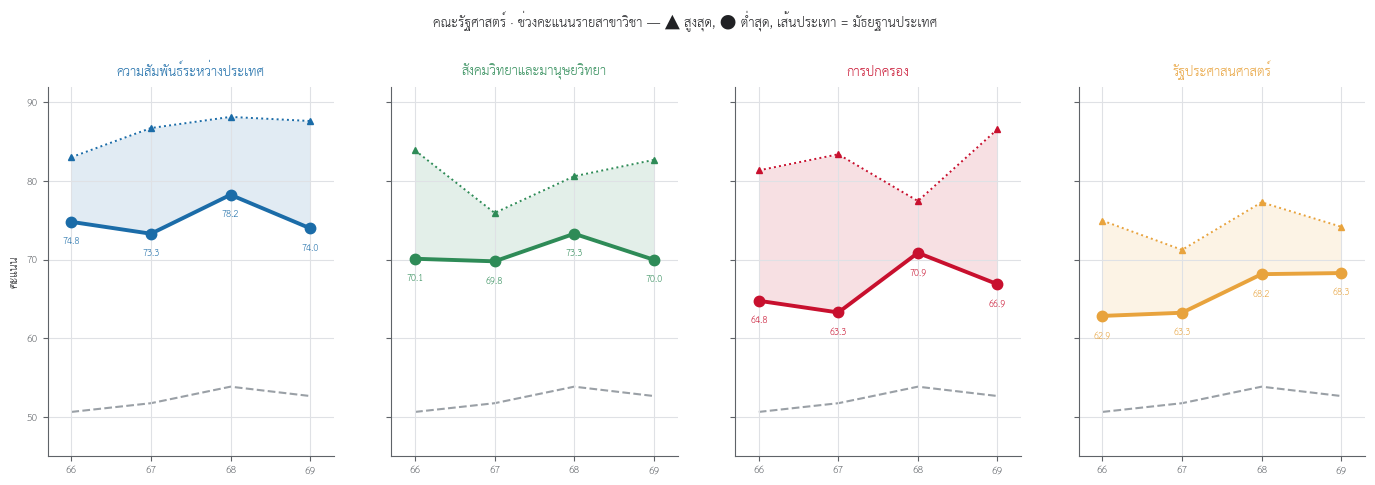

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.8), sharey=True)
for ax, m in zip(axes, MAJORS):
    g = mp[mp["major"] == m].set_index("year")
    ax.fill_between(g.index, g["floor"], g["top"], color=MCOLOR[m], alpha=.13, lw=0)
    ax.plot(g.index, g["top"], color=MCOLOR[m], lw=1.4, ls=":", marker="^", ms=5)
    ax.plot(g.index, g["floor"], color=MCOLOR[m], lw=2.8, marker="o", ms=7.5)
    ax.plot(national.index, national.values, color=viz.PALETTE["national"],
            lw=1.5, ls="--", zorder=0)
    for y, v in g["floor"].items():
        ax.annotate(f"{v:.1f}", (y, v), textcoords="offset points", xytext=(0, -16),
                    ha="center", fontsize=10, color=MCOLOR[m])
    ax.set_title(m, color=MCOLOR[m], pad=8)
    viz._year_axis(ax)
axes[0].set_ylabel("คะแนน"); axes[0].set_ylim(45, 92)
fig.suptitle("คณะรัฐศาสตร์ · ช่วงคะแนนรายสาขาวิชา — ▲ สูงสุด, ● ต่ำสุด, เส้นประเทา = มัธยฐานประเทศ",
             y=1.04, fontsize=14)
print(viz.save(fig, "09_polisci_major_bands").name)

All four floors bow upward into TCAS68 and fall back in 69. The vertical gap
between panel 1 and panel 4 is the entry-standard gap between majors — about 12
points in TCAS66, about 6 by TCAS69.

### 10 — raw points vs percentile rank

Raw points cannot separate "the major got harder" from "the papers got easier".
Ranking each major inside its own year's national distribution can.

10_polisci_raw_vs_percentile.png


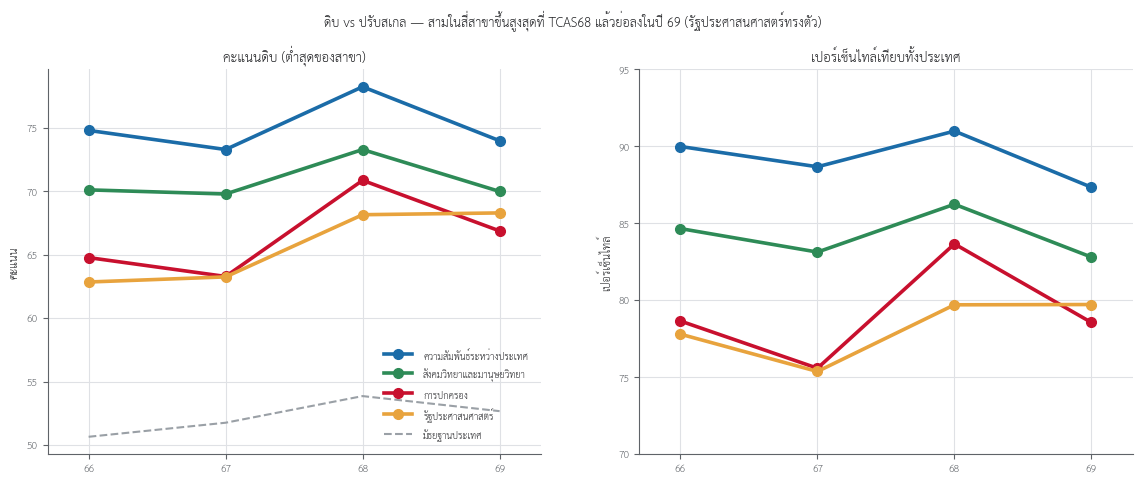

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for m in MAJORS:
    g = mp[mp["major"] == m].set_index("year")
    axes[0].plot(g.index, g["floor"], color=MCOLOR[m], lw=2.6, marker="o", ms=7, label=m)
    axes[1].plot(g.index, g["pct_rank"], color=MCOLOR[m], lw=2.6, marker="o", ms=7)
axes[0].plot(national.index, national.values, color=viz.PALETTE["national"],
             lw=1.5, ls="--", label="มัธยฐานประเทศ")
axes[0].set_title("คะแนนดิบ (ต่ำสุดของสาขา)"); axes[0].set_ylabel("คะแนน")
axes[1].set_title("เปอร์เซ็นไทล์เทียบทั้งประเทศ"); axes[1].set_ylabel("เปอร์เซ็นไทล์")
axes[1].set_ylim(70, 95)
for ax in axes:
    viz._year_axis(ax)
axes[0].legend(fontsize=10, loc="lower right")
fig.suptitle("ดิบ vs ปรับสเกล — สามในสี่สาขาขึ้นสูงสุดที่ TCAS68 แล้วย่อลงในปี 69 (รัฐประศาสนศาสตร์ทรงตัว)",
             y=1.0, fontsize=13.5)
print(viz.save(fig, "10_polisci_raw_vs_percentile").name)

The two panels agree on shape, which is the useful result: the TCAS68 peak
survives normalisation, so it is not merely an easy-paper year. The percentile
panel also shows the four majors sit between the **75th and 91st** national
percentile throughout — even the faculty's easiest entry is well above the
national median in every year.

### 11 — demand against the bar

Applications indexed to TCAS66, beside applications per admitted student. Seats
are fixed (§2), so these two panels are the same information twice: what changed
is entirely the numerator.

11_polisci_demand.png


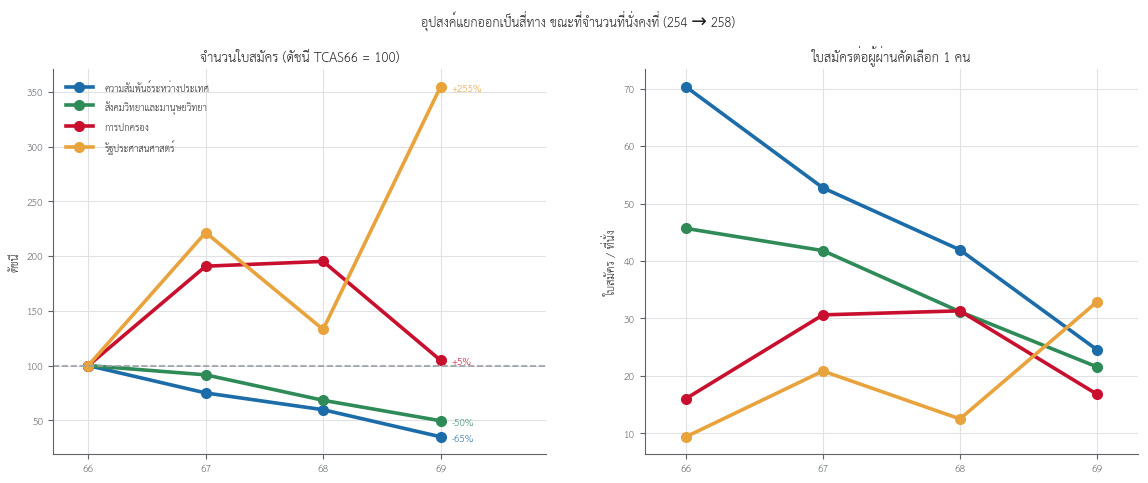

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for m in MAJORS:
    g = mp[mp["major"] == m].set_index("year")
    axes[0].plot(g.index, 100 * g["applied"] / g["applied"].loc[66],
                 color=MCOLOR[m], lw=2.6, marker="o", ms=7, label=m)
    axes[1].plot(g.index, g["apps_per_admit"], color=MCOLOR[m], lw=2.6, marker="o", ms=7)
    axes[0].annotate(f"{100*(g['applied'].loc[69]/g['applied'].loc[66]-1):+.0f}%",
                     (69, 100 * g["applied"].loc[69] / g["applied"].loc[66]),
                     textcoords="offset points", xytext=(8, -3), fontsize=10.5,
                     color=MCOLOR[m])
axes[0].axhline(100, color=viz.PALETTE["national"], ls="--", lw=1.2)
axes[0].set_title("จำนวนใบสมัคร (ดัชนี TCAS66 = 100)"); axes[0].set_ylabel("ดัชนี")
axes[1].set_title("ใบสมัครต่อผู้ผ่านคัดเลือก 1 คน"); axes[1].set_ylabel("ใบสมัคร / ที่นั่ง")
for ax in axes:
    viz._year_axis(ax)
axes[0].set_xlim(65.7, 69.9); axes[0].legend(fontsize=10, loc="upper left")
fig.suptitle("อุปสงค์แยกออกเป็นสี่ทาง ขณะที่จำนวนที่นั่งคงที่ (254 → 258)",
             y=1.0, fontsize=13.5)
print(viz.save(fig, "11_polisci_demand").name)

The four lines fan apart completely. Compare with figure 10: nothing in the
score panels has this shape. ความสัมพันธ์ฯ falls to 35% of its TCAS66
applications while its floor stays flat, and รัฐประศาสนศาสตร์ triples while its
floor moves five points.

### 12 — every route, every year

The full grain. Colour is the route's floor; hatched cells drew applications but
admitted nobody (`admits / applications`); dotted cells were never published.

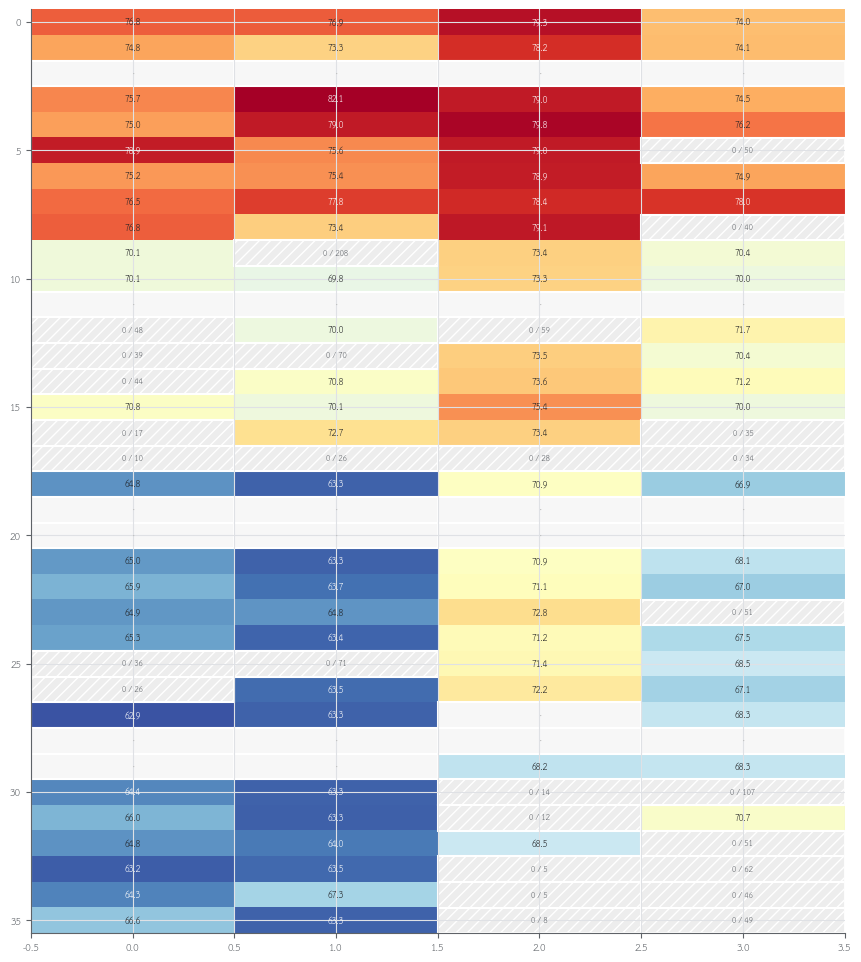

In [24]:
idx = [(m, e) for m in MAJORS for e in ELECTIVES]
rp = route_panel.set_index(["major", "elective", "year"])
score = rp["min_score"].unstack().reindex(idx)
adm = rp["passed"].unstack().reindex(idx)
app = rp["applied"].unstack().reindex(idx)

fig, ax = plt.subplots(figsize=(10.5, 12))
im = ax.imshow(score.values, aspect="auto", cmap="RdYlBu_r", vmin=62, vmax=80)
for i in range(len(idx)):
    for j in range(4):
        a, p, v = app.values[i, j], adm.values[i, j], score.values[i, j]
        if np.isnan(a):
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fc="#F7F7F7", ec="white", lw=1.5))
            ax.text(j, i, "·", ha="center", va="center", color="#BDBDBD", fontsize=15)
        elif p == 0:
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fc="#EDEDED", ec="white",
                                       lw=1.5, hatch="///"))
            ax.text(j, i, f"0 / {a:.0f}", ha="center", va="center", fontsize=8.5, color="#5F6368")
        else:
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9.5,
                    color="white" if v > 77 or v < 64.5 else "#202124")

In [25]:
ax.set_xticks(range(4)); ax.set_xticklabels(YEARS, fontsize=12)
ax.set_yticks(range(len(idx))); ax.set_yticklabels([e for _, e in idx], fontsize=10)
for k in range(1, 4):
    ax.axhline(k * len(ELECTIVES) - .5, color=viz.PALETTE["ink"], lw=2)
for k, m in enumerate(MAJORS):
    ax.text(-2.9, k * len(ELECTIVES) + (len(ELECTIVES) - 1) / 2, m, rotation=90,
            va="center", ha="center", fontsize=12, color=MCOLOR[m])
ax.grid(False); ax.set_xlim(-.5, 3.5)
fig.colorbar(im, ax=ax, shrink=.35, pad=.02).set_label("คะแนนต่ำสุด", fontsize=11)
ax.set_title("คะแนนต่ำสุดรายช่องทางเลือกสอบ\nแรเงา = มีผู้สมัครแต่ไม่รับใคร (รับ / สมัคร)  ·  จุด = ไม่เปิดช่องทางนี้",
             fontsize=12, pad=14)
print(viz.save(fig, "12_polisci_routes").name)

12_polisci_routes.png


Read down a block and the colour is nearly constant — that is §7's one-pool
result made visual. Read across รัฐประศาสนศาสตร์ and the TCAS68 restructure is
unmistakable: the block turns to hatching, and `ภาษาอังกฤษ` switches on.

`สังคมวิทยาฯ · ภาษาสเปน` is hatched all four years — a route published every
year that has never admitted anybody.

### 13 — how admits are distributed across routes

13_polisci_route_concentration.png


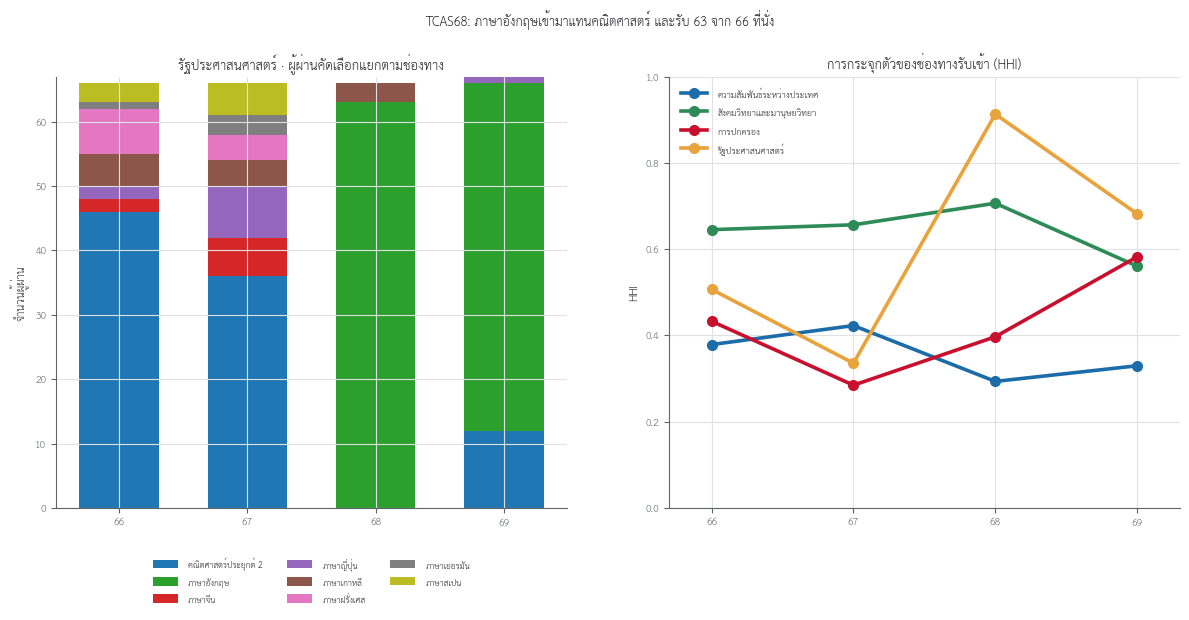

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6))
pa_adm = (route_panel[route_panel["major"] == "รัฐประศาสนศาสตร์"]
          .pivot_table(index="year", columns="elective", values="passed")
          .reindex(columns=ELECTIVES).fillna(0))
bottom = np.zeros(4)
cmap = plt.get_cmap("tab20")
for k, e in enumerate(ELECTIVES):
    if pa_adm[e].sum() == 0:
        continue
    axes[0].bar(pa_adm.index, pa_adm[e], .62, bottom=bottom, label=e, color=cmap(k / 10))
    bottom += pa_adm[e].values
axes[0].set_title("รัฐประศาสนศาสตร์ · ผู้ผ่านคัดเลือกแยกตามช่องทาง")
axes[0].set_ylabel("จำนวนผู้ผ่าน"); axes[0].set_xticks(list(YEARS))
axes[0].legend(fontsize=9, ncol=3, loc="upper center", bbox_to_anchor=(.5, -.09))

for m in MAJORS:
    h = conc.reset_index(); h = h[h["major"] == m].set_index("year")
    axes[1].plot(h.index, h["HHI"], color=MCOLOR[m], lw=2.6, marker="o", ms=7, label=m)
axes[1].set_title("การกระจุกตัวของช่องทางรับเข้า (HHI)"); axes[1].set_ylabel("HHI")
axes[1].set_ylim(0, 1); viz._year_axis(axes[1]); axes[1].legend(fontsize=9.5)
fig.suptitle("TCAS68: ภาษาอังกฤษเข้ามาแทนคณิตศาสตร์ และรับ 63 จาก 66 ที่นั่ง", y=1.0, fontsize=13.5)
print(viz.save(fig, "13_polisci_route_concentration").name)

The left panel is the restructure in one image: a broad seven-route intake in
TCAS66–67 becomes a single English route in TCAS68, then settles into an
English + maths pair in 69. The right panel shows no other major does anything
like this.

---
## 10. Write outputs

In [27]:
major_out = PROCESSED / "polisci_major_panel.csv"
route_out = PROCESSED / "polisci_route_panel.csv"
major_panel.round(4).to_csv(major_out)
route_panel.round(4).to_csv(route_out, index=False)
for p in (major_out, route_out):
    print(f"{p.name:28s} {p.stat().st_size / 1024:7.1f} KB")

polisci_major_panel.csv          2.0 KB
polisci_route_panel.csv         14.3 KB


---
## What this notebook concludes

1. **The faculty-level +3.7 is less than half real.** Every
   composition-controlled measure gives **+1.7**. รัฐประศาสนศาสตร์'s cheap
   routes stopped admitting anyone and so left the median — the bottom of the
   distribution was deleted, not raised. Any faculty with a restructured program
   needs this check before its median is quoted.

2. **Supply is frozen, so every move is demand- or criteria-side.** Quota equals
   admits in all 16 major-years (254 → 258 seats). รัฐศาสตร์ is the clean case of
   Trap 1: exactly one quota per major-year, fully reconstructable, unlike the
   faculty-wide picture where seats are unusable.

3. **Applications and the bar are close to unrelated.** ความสัมพันธ์ฯ lost
   **65%** of its applications and its floor moved **−0.8**; competition fell
   from 70.3 applications per seat to 24.6 with no measurable easing. This is the
   project's headline tension reproduced inside one faculty, with seats provably
   fixed.

4. **Three of four majors peaked in TCAS68 and gave it back in 69**, on raw
   points and percentile alike — a cohort effect, only partly exam drift. For
   ความสัมพันธ์ฯ and สังคมวิทยาฯ most of the raw spike *is* drift (+3.4/+3.2 raw
   against a national +3.2). รัฐประศาสนศาสตร์ is the exception that held its
   gain, and it is the major that restructured.

5. **รัฐประศาสนศาสตร์ restructured in TCAS68**: `ภาษาอังกฤษ` replaced
   `คณิตศาสตร์ประยุกต์ 2` and took 63 of 66 admits; HHI 0.34 → 0.91. This single
   change drives most of the faculty-level rise in §8.

6. **Elective routes are one ranked pool, not separate contests.** Floors within
   a major sit ~2 points apart against a ~12-point gap between majors, and every
   wide spread traces to a route with one or two admits.

7. **525 applications in TCAS69 (8.4% of the faculty's total) went to routes that
   admitted nobody.**

### What this cannot determine

- **Why any floor moved.** เกณฑ์ and subject weightings are not in this file. The
  TCAS68 restructure is *visible* here but its rationale is not.
- **Whether dead routes were formally closed** or simply lost a common ranking.
  Both produce the identical published row.
- **Anything about individual applicants.** `สมัคร` counts applications; one
  student holds up to 10 choices and may appear in several majors here.
- **Whether TCAS69's pullback is a turning point or noise.** It is one year, and
  `nb/05_model` establishes that per-program trends are not estimable at n = 4.